# Explore here

In [57]:
#PASO1
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine


#PASO 2

#url de endpoint country
url = "https://api.worldbank.org/v2/country"

#parámetros para definir como servir los datos
params = {
    "format": "json",
    "per_page": 50,
    "page": 1
}
#url de endpoint indicator
url_indicador="https://api.worldbank.org/v2/indicator"


#solicitud get a la api
response = requests.get(url, params=params, timeout=30)
#Método de requests que lanza un error automáticamente si la petición falló
response.raise_for_status() 
#convierte el json en un diccionario de python
payload=response.json()


#descarga del url de indicator
response_ind=requests.get(url_indicador,params=params,timeout=30)
response_ind.raise_for_status()
payload_ind=response_ind.json()

# payload[0] -> metadatos de paginacion
# payload[1] -> datos de la pagina actual
print(response.status_code)
print("Metadatos:", payload[0])
print("Primer elemento:", payload[1][0])
print("Metadatos:",payload_ind[0])
print("Primer elemento:", payload_ind[1][0])






200
Metadatos: {'page': 1, 'pages': 6, 'per_page': '50', 'total': 296}
Primer elemento: {'id': 'ABW', 'iso2Code': 'AW', 'name': 'Aruba', 'region': {'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Latin America & Caribbean '}, 'adminregion': {'id': '', 'iso2code': '', 'value': ''}, 'incomeLevel': {'id': 'HIC', 'iso2code': 'XD', 'value': 'High income'}, 'lendingType': {'id': 'LNX', 'iso2code': 'XX', 'value': 'Not classified'}, 'capitalCity': 'Oranjestad', 'longitude': '-70.0167', 'latitude': '12.5167'}
Metadatos: {'page': 1, 'pages': 591, 'per_page': '50', 'total': 29511}
Primer elemento: {'id': '1.0.HCount.1.90usd', 'name': 'Poverty Headcount ($1.90 a day)', 'unit': '', 'source': {'id': '37', 'value': 'LAC Equity Lab'}, 'sourceNote': 'The poverty headcount index measures the proportion of the population with daily per capita income (in 2011 PPP) below the poverty line.', 'sourceOrganization': 'LAC Equity Lab tabulations of SEDLAC (CEDLAS and the World Bank).', 'topics': [{'id': '11', 'value': 

In [58]:
#PASO3 DESCARGAR SERIES TEMPORALES DE 2010-2024 
#(se revisa en datahelp la estructura para el pi para date-range)

#lista de id de paises
country=["ABW","AUT","ASM","AUS","ATG"]
indicator=["SP.POP.TOTL","NY.GDP.PCAP.CD","SP.DYN.LE00.IN"]
lista_population=[]
lista_pib=[]
lista_esperanza_vida=[]
for i in country:
    #url con parametros necesarios considernado los paises escogidos y con el indicador (población total)
    for ind in indicator:
        url_year=f"https://api.worldbank.org/v2/country/{i}/indicator/{ind}?date=2010:2024"
        #solicitud get a la api
        response_year = requests.get(url_year, params=params, timeout=30)
        #Método de requests que lanza un error automáticamente si la petición falló
        response_year.raise_for_status()
        #convierte el json en un diccionario de python
        payload_year=response_year.json()

        #iterar por valores dentro del segundo registro de payload_year para separar los que se necesita 
        for j in payload_year[1]:
            #CONDICIONALES POR CADA INDICADOR PARA GENERAR LUEGO 3 TABLAS
            if ind == "SP.POP.TOTL":
                lista_population.append({
                "country":j["country"]["value"],
                "year":j["date"],
                "value":j["value"]
                })
            elif ind == "NY.GDP.PCAP.CD":
                lista_pib.append({
                "country":j["country"]["value"],
                "year":j["date"],
                "value_pib":j["value"]
                })
            elif ind == "SP.DYN.LE00.IN":    
                lista_esperanza_vida.append({
                "country":j["country"]["value"],
                "year":j["date"],
                "value_esperanza_vida":j["value"]
                })
#dataframe de lista para extraer la tabla
df_population = pd.DataFrame(lista_population)
df_pib=pd.DataFrame(lista_pib)
df_esperanza_vida=pd.DataFrame(lista_esperanza_vida)
print(df_population)
print(df_pib)
print(df_esperanza_vida)



                country  year   value
0                 Aruba  2024  107995
1                 Aruba  2023  107359
2                 Aruba  2022  107310
3                 Aruba  2021  107700
4                 Aruba  2020  108587
..                  ...   ...     ...
70  Antigua and Barbuda  2014   88765
71  Antigua and Barbuda  2013   88064
72  Antigua and Barbuda  2012   87260
73  Antigua and Barbuda  2011   86332
74  Antigua and Barbuda  2010   85320

[75 rows x 3 columns]
                country  year     value_pib
0                 Aruba  2024  39498.594129
1                 Aruba  2023  35718.753119
2                 Aruba  2022  30975.998912
3                 Aruba  2021  26749.329609
4                 Aruba  2020  22759.807175
..                  ...   ...           ...
70  Antigua and Barbuda  2014  15532.106206
71  Antigua and Barbuda  2013  15051.511359
72  Antigua and Barbuda  2012  15639.807811
73  Antigua and Barbuda  2011  14911.727508
74  Antigua and Barbuda  2010  15217.

In [59]:
#PASO4 LIMPIEZA

#limpieza df_population
df_population_limpio=df_population.dropna(subset=["value"])
df_population_limpio["value"] = df_population_limpio["value"].astype(int)
df_population_limpio["year"] = df_population_limpio["year"].astype(int)

#limpieza df_pib
df_pib_limpio=df_pib.dropna(subset=["value_pib"])
df_pib_limpio["value_pib"] = df_pib_limpio["value_pib"].astype(float)
df_pib_limpio["value_pib"] = df_pib_limpio["value_pib"].round(2)
df_pib_limpio["year"] = df_pib_limpio["year"].astype(int)

#limpieza de df_esperanza
df_esperanza_vida_limpio=df_esperanza_vida.dropna(subset=["value_esperanza_vida"]) 
#quitar nulos si es que hay algun nulo en columna value
df_esperanza_vida_limpio["value_esperanza_vida"] = df_esperanza_vida_limpio["value_esperanza_vida"].astype(float)
df_esperanza_vida_limpio["value_esperanza_vida"] = df_esperanza_vida_limpio["value_esperanza_vida"].round(2)
df_esperanza_vida_limpio["year"] = df_esperanza_vida_limpio["year"].astype(int)

print(df_population_limpio)
print(df_pib_limpio)
print(df_esperanza_vida_limpio)


                country  year   value
0                 Aruba  2024  107995
1                 Aruba  2023  107359
2                 Aruba  2022  107310
3                 Aruba  2021  107700
4                 Aruba  2020  108587
..                  ...   ...     ...
70  Antigua and Barbuda  2014   88765
71  Antigua and Barbuda  2013   88064
72  Antigua and Barbuda  2012   87260
73  Antigua and Barbuda  2011   86332
74  Antigua and Barbuda  2010   85320

[75 rows x 3 columns]
                country  year  value_pib
0                 Aruba  2024   39498.59
1                 Aruba  2023   35718.75
2                 Aruba  2022   30976.00
3                 Aruba  2021   26749.33
4                 Aruba  2020   22759.81
..                  ...   ...        ...
70  Antigua and Barbuda  2014   15532.11
71  Antigua and Barbuda  2013   15051.51
72  Antigua and Barbuda  2012   15639.81
73  Antigua and Barbuda  2011   14911.73
74  Antigua and Barbuda  2010   15217.40

[73 rows x 3 columns]
      

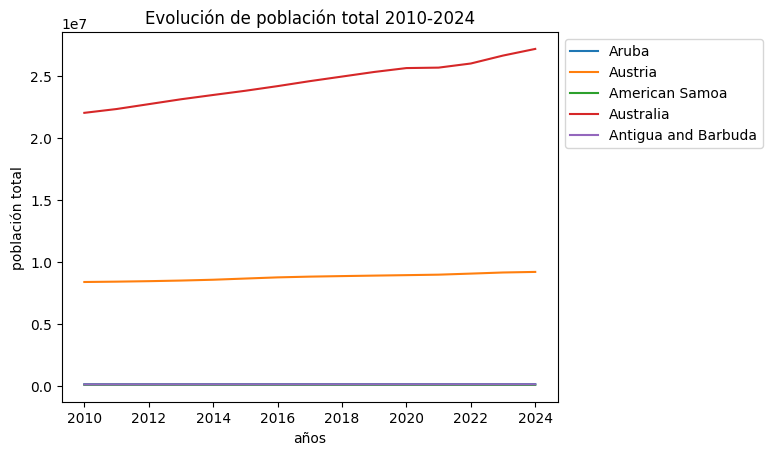

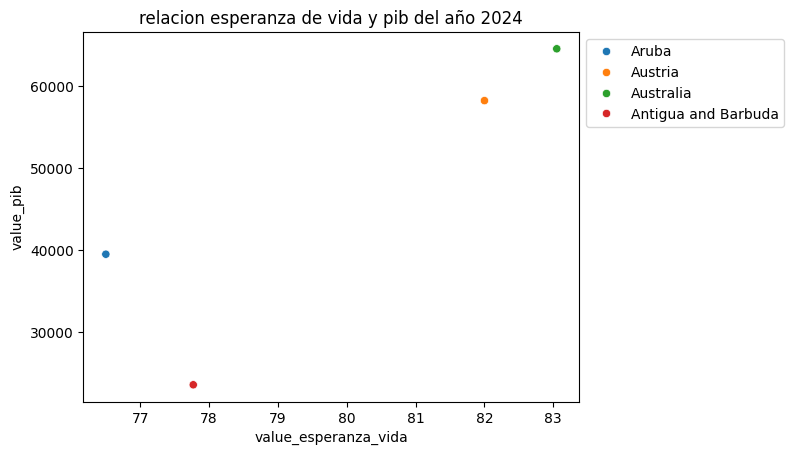

In [60]:
#PASO 5
#datos para gráfico de lineas
sns.lineplot(data=df_population_limpio, x="year", y="value", hue="country")
plt.xlabel("años")
plt.ylabel("población total")
plt.title("Evolución de población total 2010-2024")
plt.legend(bbox_to_anchor=(1,1), #son coordenadas desde el gráfico para seleccionar desde donde se ubicará la leyenda 1,1 es la esquina derecha
           loc='upper left')#leyenda no tapa el gráfico
plt.show()

#datos spara tabla de scatter plot
#pd.merge para unir la tabla de df_esperanza_vida y df_pib
df_grafico_2 = pd.merge(df_pib_limpio, df_esperanza_vida_limpio, on=["country", "year"])
df_grafico_2_nuevo=df_grafico_2[df_grafico_2["year"]==2024]
sns.scatterplot(data=df_grafico_2_nuevo, #seleccion de df
                x="value_esperanza_vida", #definir eje x
                y="value_pib", #definir eje y
                hue="country")#para diferenciar por una tercera variable
plt.legend(bbox_to_anchor=(1,1), #son coordenadas desde el gráfico para seleccionar desde donde se ubicará la leyenda 1,1 es la esquina derecha
           loc='upper left')#leyenda no tapa el gráfico

plt.title("relacion esperanza de vida y pib del año 2024")
plt.show()



In [71]:
#PASO6,, da error con sqlalchemy, dice que no es compatible con version de pandas , se actualizó pero no me da el resultado
import sqlite3
#conexión
conn = sqlite3.connect("world_bank_analysis.db")
#diccionarios de tablas por cada df
tables = {
    "population": df_population_limpio,
    "pib": df_pib_limpio,
    "esperanza_vida": df_esperanza_vida_limpio
}
# iterar sobre cada indicador y guardarlo como tabla en la base de datos
for i, df_sql in tables.items():
    #nombre de tabla con el prefijo indicador_
    sql_table_name = f"indicador_{i}"
    #guardar cada cf como tabla sql
    df_sql.to_sql(sql_table_name, conn, if_exists="replace", index=False)

#prueba de los valores de la tabla en sql
prueba = pd.read_sql("SELECT * FROM indicador_population LIMIT 5", conn)
print(prueba)

conn.close()



  country  year   value
0   Aruba  2024  107995
1   Aruba  2023  107359
2   Aruba  2022  107310
3   Aruba  2021  107700
4   Aruba  2020  108587
